# Analisi statistica e modellazione predittiva delle proprietà meccaniche di componenti stampati in 3D mediante tecnologia FDM.

L'analisi di seguito presentata utilizza i dati provenienti dal dataset '*3D Printer Dataset for Mechanical Engineers*' (disponibile al link kaggle https://www.kaggle.com/datasets/afumetto/3dprinter) per analizzare e trovare relazioni tra i parametri di processo utilizzati per stampare dei provini in materiale plastico ed il loro comportamento meccanico successivamente testato.
<img src="Introduzione.png" style="display: block; margin-left: auto; margin-right: auto;" width="500">
Per ricavare i records presenti nel dataset sono stati prodotti tramite **stampante 3D FDM Ultimaker S5 3-D**, utilizzando diversi settings di stampa (vedi *Par.1 'Data Understanding e Cleansing'*), **50 campioni in materiale *PLA* e *ABS*** che sono stati successivamente testati tramite rugosimetro e pull tester **Sincotec GMBH** per valutarne le proprietà meccaniche.

L'obiettivo dello studio è analizzare statisticamente i valori dei test ottenuti (*Par.2.1 Data Analysis - Analisi univariabile*), valutare la presenza ed entità di correlazioni tra i parametri in gioco (*Par.2.2 Data Analysis - Analisi di correlazione*), ed infine cercare di costruire dei modelli predittivi in grado di prevedere le caratteristiche del materiale stampato (rugosità e resistenza a trazione) sulla base dei parametri di stampa impostati (*Par.3 Data Prediction*).

- [0. Importazione Dataset](#0.-Importazione-Dataset)
- [1. Data Understanding e Cleansing](#1.-Data-Understanding-e-Cleansing)-
- [2. Data Analysis](#2.-Data-Analysis)
    - [2.1 Analisi Univariabile](#2.1-Analisi-Univariabile)
      - [2.1.1 Variabili Categoriche: Distribuzione materiali e pattern di riempimento](#2.1.1-Variabili-Categoriche:-Distribuzione-materiali-e-pattern-di-riempimento)
      - [2.1.2 Variabili Numeriche: Statistiche parametri di stampa e Risultati test meccanici](#2.1.2-Variabili-Numeriche:-Statistiche-parametri-di-stampa-e-Risultati-test-meccanici)
    - [2.2 Analisi di Correlazione](#2.2-Analisi-di-Correlazione)
      - [2.2.1 Correlazione Layer height | Roughness](#2.2.1-Correlazione-Layer-height-|-Roughness)
      - [2.2.2 Correlazione Infill Density & Wall thickness | Tension Strenght](#2.2.2-Correlazione-Infill-Density-&-Wall-thickness-|-Tension-Strenght)
      - [2.2.3 Nozzle temperature & Fan speed | Elongation](#2.2.3-Nozzle-temperature-&-Fan-speed-|-Elongation)
- [3. Data Prediction](#3.-Data-Prediction)
  - [3.1 Modello di predizione della Rugosità](#3.1-Modello-di-predizione-della-Rugosità)
  - [3.2 Modello di predizione della Resistenza meccanica](#3.2-Modello-di-predizione-della-Resistenza-meccanica)
- [4. Conclusioni](#4.-Conclusioni)

## 0. Importazione Dataset

In [883]:
#importazione dataset da kaggle
import os
# Punta alla cartella kaggle
os.environ["KAGGLE_CONFIG_DIR"] = os.path.expanduser("~/.kaggle")
# Scarica e decomprimi nella cartella ./data
!kaggle datasets download -d afumetto/3dprinter --unzip -p ./data

Dataset URL: https://www.kaggle.com/datasets/afumetto/3dprinter
License(s): unknown




  0%|          | 0.00/196k [00:00<?, ?B/s]
100%|##########| 196k/196k [00:00<00:00, 761kB/s]
100%|##########| 196k/196k [00:00<00:00, 761kB/s]


In [884]:
files = os.listdir("./data")
print(files)

['3dprinter.html', '3dprinter.ipynb', 'data.csv', 'printer_dataset.py']


In [885]:
import pandas as pd

df = pd.read_csv("./data/data.csv")
df.head(10)

,layer_height,wall_thickness,infill_density,infill_pattern,nozzle_temperature,bed_temperature,print_speed,material,fan_speed,roughness,tension_strenght,elongation
0,0.02,8,90,grid,220,60,40,abs,0,25,18,1.2
1,0.02,7,90,honeycomb,225,65,40,abs,25,32,16,1.4
2,0.02,1,80,grid,230,70,40,abs,50,40,8,0.8
3,0.02,4,70,honeycomb,240,75,40,abs,75,68,10,0.5
4,0.02,6,90,grid,250,80,40,abs,100,92,5,0.7
5,0.02,10,40,honeycomb,200,60,40,pla,0,60,24,1.1
6,0.02,5,10,grid,205,65,40,pla,25,55,12,1.3
7,0.02,10,10,honeycomb,210,70,40,pla,50,21,14,1.5
8,0.02,9,70,grid,215,75,40,pla,75,24,27,1.4
9,0.02,8,40,honeycomb,220,80,40,pla,100,30,25,1.7


## 1. Data Understanding e Cleansing

In [887]:
print(df.shape)
print(df.info())

(50, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   layer_height        50 non-null     float64
 1   wall_thickness      50 non-null     int64  
 2   infill_density      50 non-null     int64  
 3   infill_pattern      50 non-null     object 
 4   nozzle_temperature  50 non-null     int64  
 5   bed_temperature     50 non-null     int64  
 6   print_speed         50 non-null     int64  
 7   material            50 non-null     object 
 8   fan_speed           50 non-null     int64  
 9   roughness           50 non-null     int64  
 10  tension_strenght    50 non-null     int64  
 11  elongation          50 non-null     float64
dtypes: float64(2), int64(8), object(2)
memory usage: 4.8+ KB
None


Il dataset contiene 12 colonne:
- Le colonne da 0 a 8 rappresentano le **features** del dataset, ovvero i **parametri noti** utilizzati durante lo stampaggio 3D dei componenti
- Le colonne da 9 a 11 rappresentano le **labels**, ovvero il comportamento meccanico e morfologico del componente (misurati a monte del processo produttivo) **di cui si vogliono predirre i valori**.

Le unità di misura dei parametri di stampa e delle caratteristiche meccaniche dei pezzi stampati sono i seguenti:

| Column # | Feature | Unit |
|:------:|:-------:|:----:|
| 0 | Layer Height | mm |
| 1 | Wall Thickness | mm |
| 2 | Infill Density | % |
| 3 | Infill Pattern | Grid / Honeycomb |
| 4 | Nozzle Temperature | °C |
| 5 | Bed Temperature | °C |
| 6 | Print Speed | mm/s |
| 7 | Material | ABS / PLA |
| 8 | Fan Speed | % |
| 9 | Roughness | µm |
| 10 | Tensile Strength | MPa |
| 11 | Elongation | % |

I pattern di riempimento utilizzati, che influenzano la velocità di stampa ma soprattutto le proprietà morfologiche e meccaniche finali del componente, sono il riempimento a griglia (**grid**) e a nido d'ape (**honeycomb**). Di seguito viene riportata un'immagine per capirne la differenza.

![infill_patterns_grid_honeycomb](The-infill-pattern-1-Grid-2-Rectilinear-3-Honeycomb.png)

In [890]:
#Panoramica descrittiva dei dati quantitativi delle varie colonne del dataset
df.describe()

,layer_height,wall_thickness,infill_density,nozzle_temperature,bed_temperature,print_speed,fan_speed,roughness,tension_strenght,elongation
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.0000,50.000000,50.000000,50.000000,50.000000
mean,0.106000,5.220000,53.40000,221.500000,70.000000,64.0000,50.000000,170.580000,20.080000,1.672000
std,0.064397,2.922747,25.36348,14.820353,7.142857,29.6923,35.714286,99.034129,8.925634,0.788188
min,0.020000,1.000000,10.00000,200.000000,60.000000,40.0000,0.000000,21.000000,4.000000,0.400000
25%,0.060000,3.000000,40.00000,210.000000,65.000000,40.0000,25.000000,92.000000,12.000000,1.100000
50%,0.100000,5.000000,50.00000,220.000000,70.000000,60.0000,50.000000,165.500000,19.000000,1.550000
75%,0.150000,7.000000,80.00000,230.000000,75.000000,60.0000,75.000000,239.250000,27.000000,2.175000
max,0.200000,10.000000,90.00000,250.000000,80.000000,120.0000,100.000000,368.000000,37.000000,3.300000


Si notano i range di valori dei parametri utilizzati durante la stampa 3D e la statistica dei risultati dei test meccanici realizzati sui componenti

Come visto sopra, non sono presenti record nulli, il formato dei dati numerici è corretto (int/float), l'unica operazione di **data cleaning** da considerare è la conversione dei dati testuali da formato object a string

In [893]:
df[['infill_pattern','material']]=df[['infill_pattern','material']].astype('string')
df.dtypes

layer_height                 float64
wall_thickness                 int64
infill_density                 int64
infill_pattern        string[python]
nozzle_temperature             int64
bed_temperature                int64
print_speed                    int64
material              string[python]
fan_speed                      int64
roughness                      int64
tension_strenght               int64
elongation                   float64
dtype: object

## 2. Data Analysis

In [895]:
#importazione librerie
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid")

#### 2.1 Analisi Univariabile

L'obiettivo è comprendere la distribuzione, le caratteristiche principali e i pattern di una singola variabile senza relazionarla con altre:
- Aiuta a *individuare outlier* e valori anomali
- Permette di capire la *distribuzione* della variabili

In [898]:
#separazione feature numeriche e categoriche
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="string").columns.tolist()

##### 2.1.1 Variabili Categoriche: Distribuzione materiali e pattern di riempimento 

In [900]:
df[cat_cols].value_counts().to_frame(name='count').groupby(['material','infill_pattern']).sum()

count
material infill_pattern       
abs      grid               15
         honeycomb          10
pla      grid               10
         honeycomb          15

Sono stati stampati e testati rispettivamente 25 pezzi in ABS (15 grid/10 honeycomb) e 25 in PLA(10 grid/15 honeycomb)

##### 2.1.2 Variabili Numeriche: Statistiche parametri di stampa e Risultati test meccanici

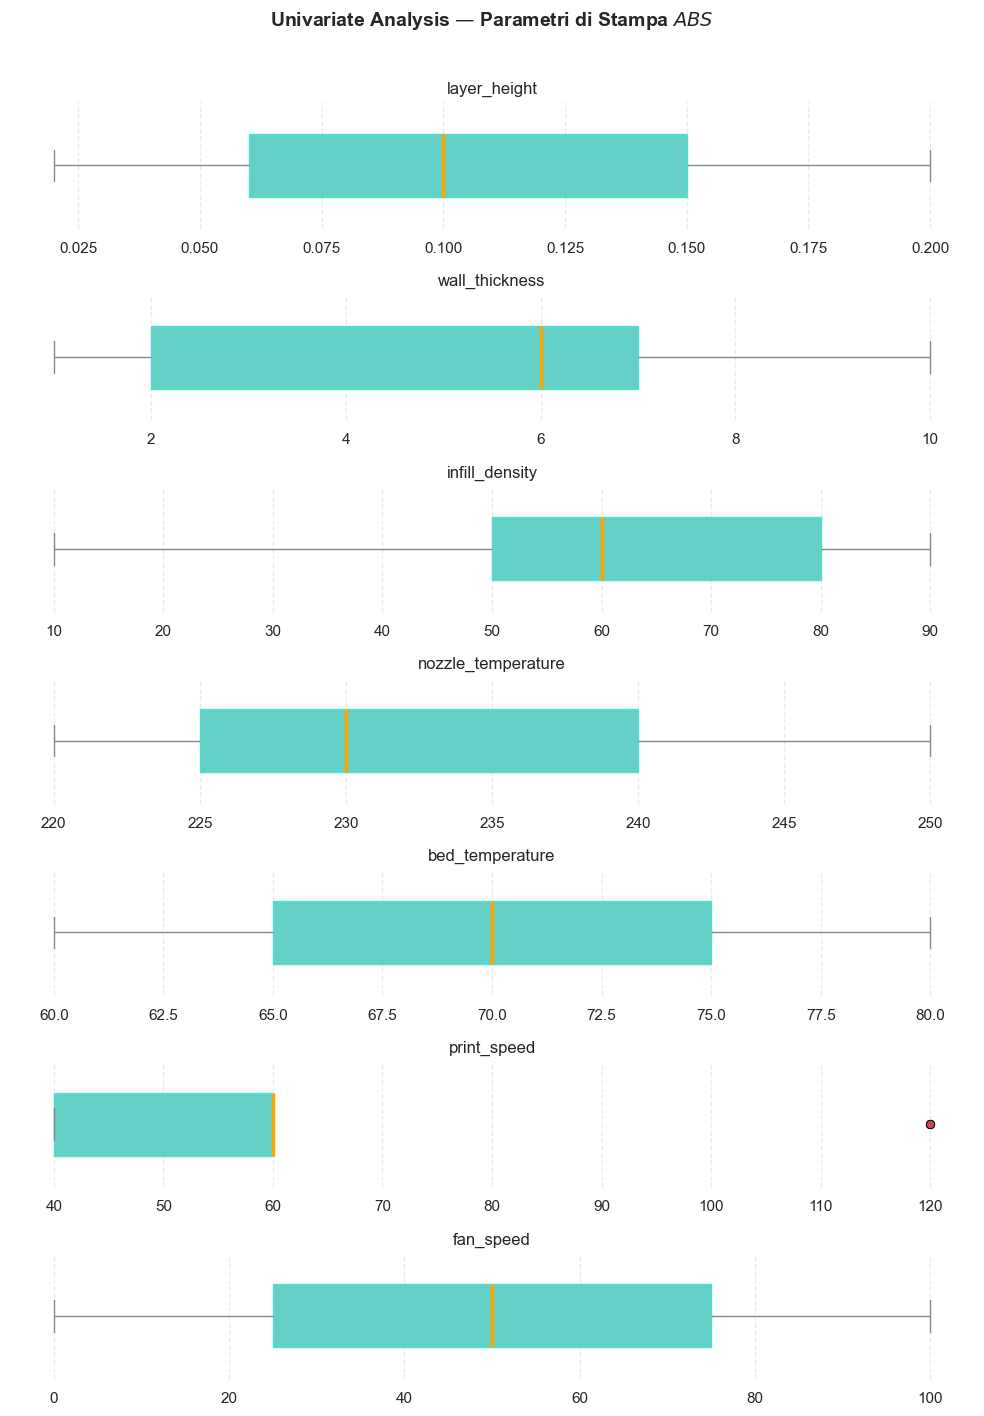

In [903]:
#boxplot con parametri di stampa utilizzati per l'ABS
df_abs=df[df['material']=='abs']

n1= len(num_cols[0:-3])
fig, axes = plt.subplots(n1, 1, figsize=(10, n1*2), squeeze=False)
fig.suptitle("Univariate Analysis — Parametri di Stampa $\\mathit{ABS}$", fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(num_cols[0:-3]):

    sns.boxplot(
            x=df_abs[col], ax=axes[i][0], color="#40e0d0", width=0.5, linewidth=1, fliersize=5, whis=1.5, 
            flierprops=dict(marker="o", markersize=6, markerfacecolor="r", markeredgecolor="black", 
            markeredgewidth=0.6, alpha=0.8, linestyle="none"), 
            boxprops=dict(alpha=0.9, edgecolor="#40e0d0"),medianprops=dict(color="#ffa500", linewidth=2.5), 
            whiskerprops=dict(color="#7F8C8D", ls="-"), capprops=dict(color="#7F8C8D")
            )
    
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel("")
    axes[i][0].grid(axis='x', linestyle='--', alpha=0.4)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("parametri_stampa_ABS.png", bbox_inches="tight")
plt.show()

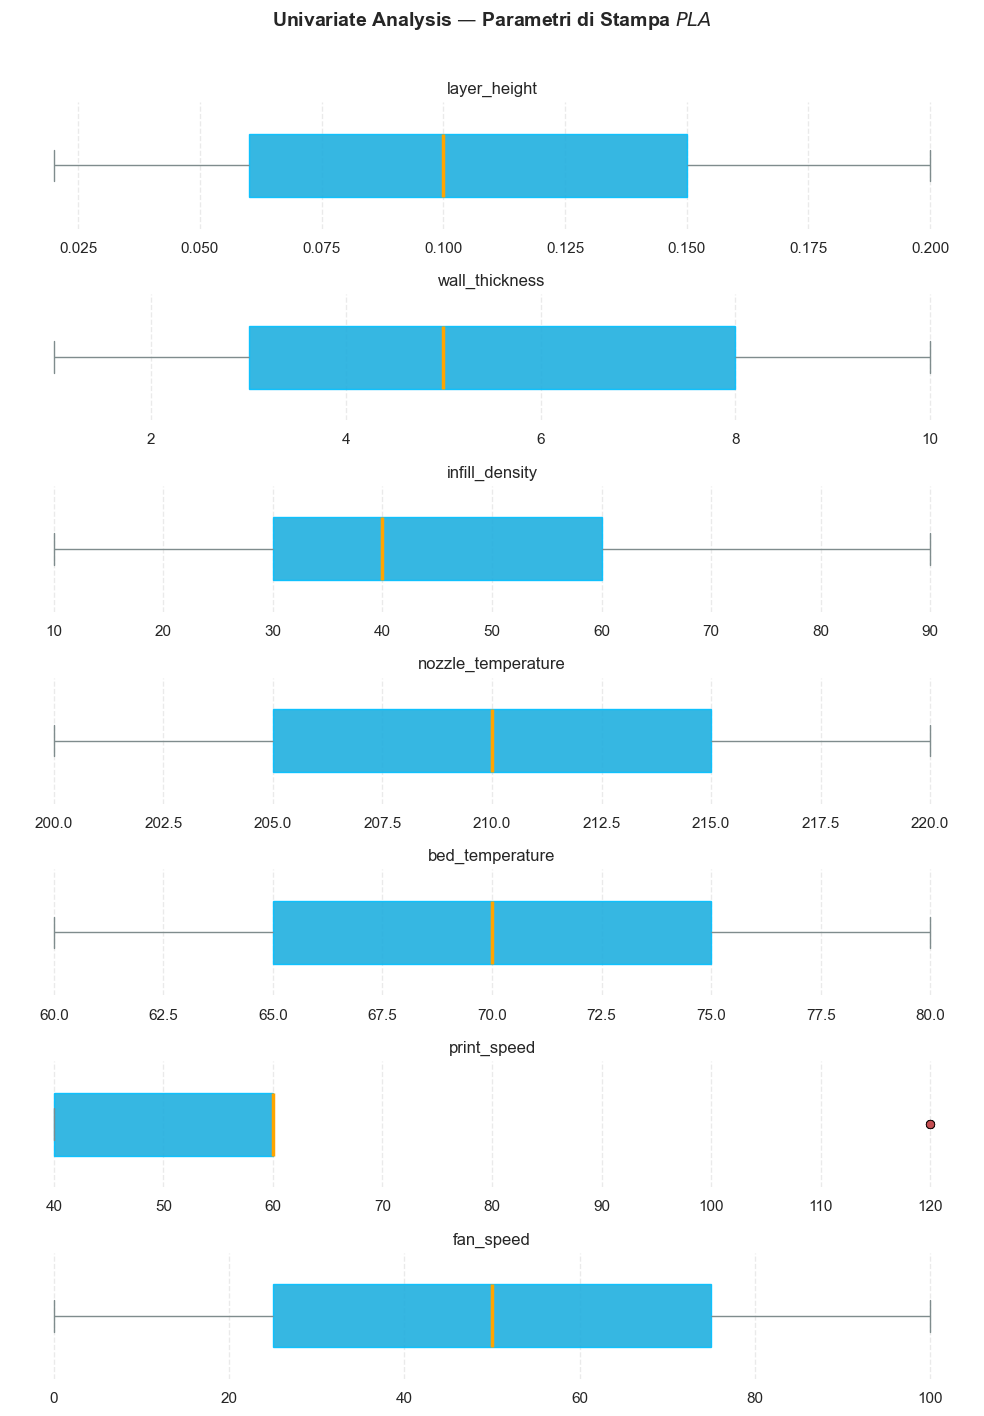

In [904]:
#boxplot con parametri di stampa utilizzati per il PLA
df_pla=df[df['material']=='pla']

fig, axes = plt.subplots(n1, 1, figsize=(10, n1*2), squeeze=False)
fig.suptitle("Univariate Analysis — Parametri di Stampa $\\mathit{PLA}$", fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(num_cols[0:-3]):

    sns.boxplot(
            x=df_pla[col], ax=axes[i][0], color="#00bfff", width=0.5, linewidth=1, fliersize=5, whis=1.5, 
            flierprops=dict(marker="o", markersize=6, markerfacecolor="r", markeredgecolor="black", 
            markeredgewidth=0.6, alpha=0.8, linestyle="none"), 
            boxprops=dict(alpha=0.9, edgecolor="#00bfff"),medianprops=dict(color="#ffa500", linewidth=2.5), 
            whiskerprops=dict(color="#7F8C8D", ls="-"), capprops=dict(color="#7F8C8D")
            )
    
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel("")
    axes[i][0].grid(axis='x', linestyle='--', alpha=0.4)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("parametri_stampa_PLA.png", bbox_inches="tight")
plt.show()

Tramite una visualizzazione a boxplot si nota più facilmente la distribuzione dei parametri di stampa utilizzati (con evidenziate le **mediane** ed eventuali valori estremi -**outlier**). 
Si nota in particolare come:
- I parametri *layer_height, bed_temperature, print_speed e fan_speed* siano stati mantenuti uguali per i due materiali stampati
- La *wall thickness* è stata impostata simile per i due materiali, con una dispersione più elevata (maggiori prove) su valori più bassi per l'ABS
- La *infill_density* (densità di riempimento) è stata settata con frequenza più elevata per l'ABS (50-80%) rispetto al PLA (30-60%)
- La *nozzle_temperature*, strettamente dipendente dalle caratteristiche del materiale da stampare, è stata variata tra 220-250°C per l'ABS e tra 200-220°C per il PLA.

Mettendo il focus sulla velocità di stampa (*print_speed*) - come detto mantenuta su valori uguali per entrambi i materiali stampati con **valore minimo** e **primo quartile** impostati a 40 mm/s, velocità **mediana** e **terzo quartile** a 60 mm/s -  salta all'occhio come sia presente un valore anomalo molto elevato (**outlier**) di 120 mm/s.

Analizziamo più in dettaglio quando è stato impostato questa velocità di stampa, per capire se si tratta di un singolo record errato oppure di un test ripetuto per valutare il comportamento del pezzo stampato in diversi materiali e pattern di riempimento scostandosi di molto dalla velocità nominale di stampa (mediana).

In [907]:
df.query('print_speed==120')

,layer_height,wall_thickness,infill_density,infill_pattern,nozzle_temperature,bed_temperature,print_speed,material,fan_speed,roughness,tension_strenght,elongation
20,0.1,1,40,grid,220,60,120,abs,0,120,16,1.2
21,0.1,2,30,honeycomb,225,65,120,abs,25,144,12,1.1
22,0.1,1,50,grid,230,70,120,abs,50,265,10,0.9
23,0.1,9,80,honeycomb,240,75,120,abs,75,312,19,0.8
24,0.1,2,60,grid,250,80,120,abs,100,368,8,0.4
25,0.1,1,50,honeycomb,200,60,120,pla,0,180,11,1.6
26,0.1,4,40,grid,205,65,120,pla,25,176,12,1.2
27,0.1,3,50,honeycomb,210,70,120,pla,50,128,18,1.8
28,0.1,4,90,grid,215,75,120,pla,75,138,34,2.9
29,0.1,1,30,honeycomb,220,80,120,pla,100,121,14,1.5


Abbiamo verificato che l'outlier indivisuato non è un errore di *data collection* bensì un test sistematico per valutare l'influenza della variabile di processo *print_speed* sul comportamento meccanico e morfologico del pezzo stampato scostandosi di molto (il doppio) dal valore nominale.

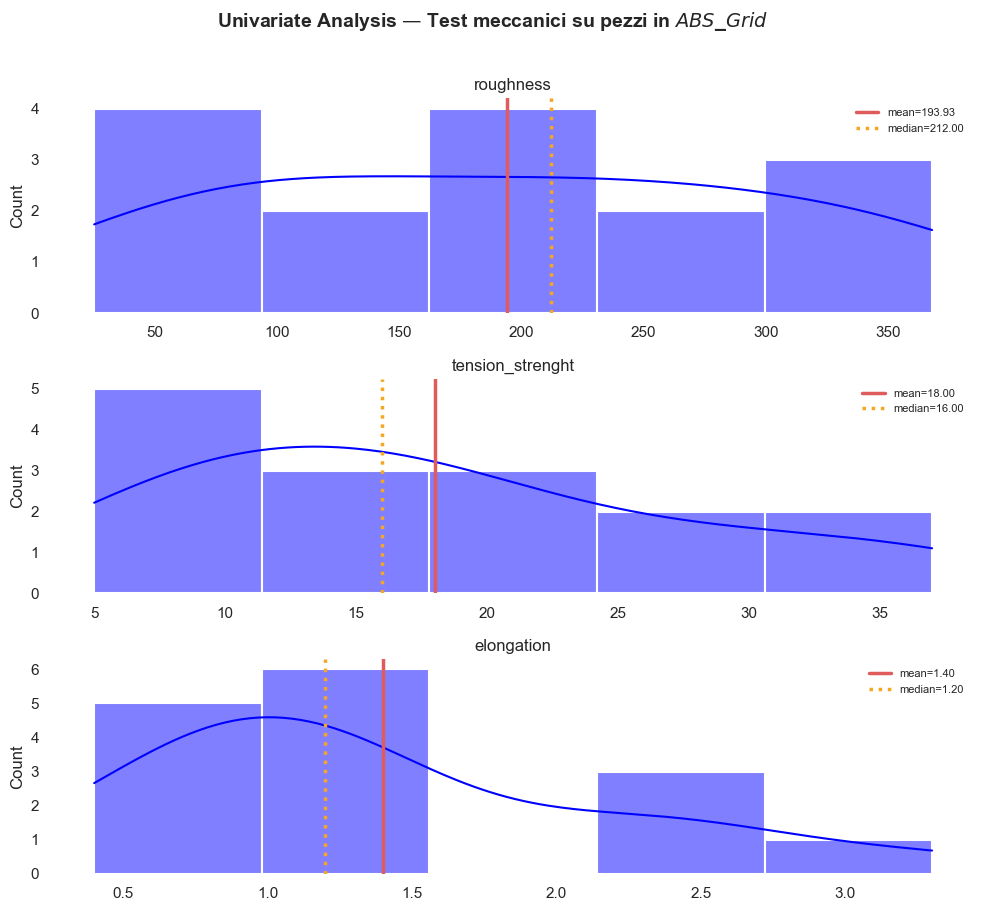

In [909]:
#test meccanici sui pezzi stampati in ABS_Grid
n2 = len(num_cols[-3:])
fig, axes = plt.subplots(n2, 1, figsize=(10, n2 * 3), squeeze=False)
fig.suptitle("Univariate Analysis — Test meccanici su pezzi in $\\mathit{ABS}$_$\\mathit{Grid}$", fontsize=14, fontweight="bold", y=1.01)

df_abs_grid=df_abs.query('infill_pattern=="grid"')
for i, col in enumerate(num_cols[-3:]):

    sns.histplot(df_abs_grid[col], ax=axes[i][0], kde=True, color="blue", bins="auto", edgecolor="white", linewidth=1.5)
    
    axes[i][0].axvline(df_abs_grid[col].mean(),   color="#E05C5C", lw=2.5, ls="-", label=f"mean={df_abs_grid[col].mean():.2f}")
    axes[i][0].axvline(df_abs_grid[col].median(), color="#F5A623", lw=2.5, ls=":",  label=f"median={df_abs_grid[col].median():.2f}")
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel("")
    axes[i][0].legend(fontsize=8, frameon=False)
    axes[i][0].grid(False)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("test_meccanici_ABS_Grid.png", bbox_inches="tight")
plt.show()

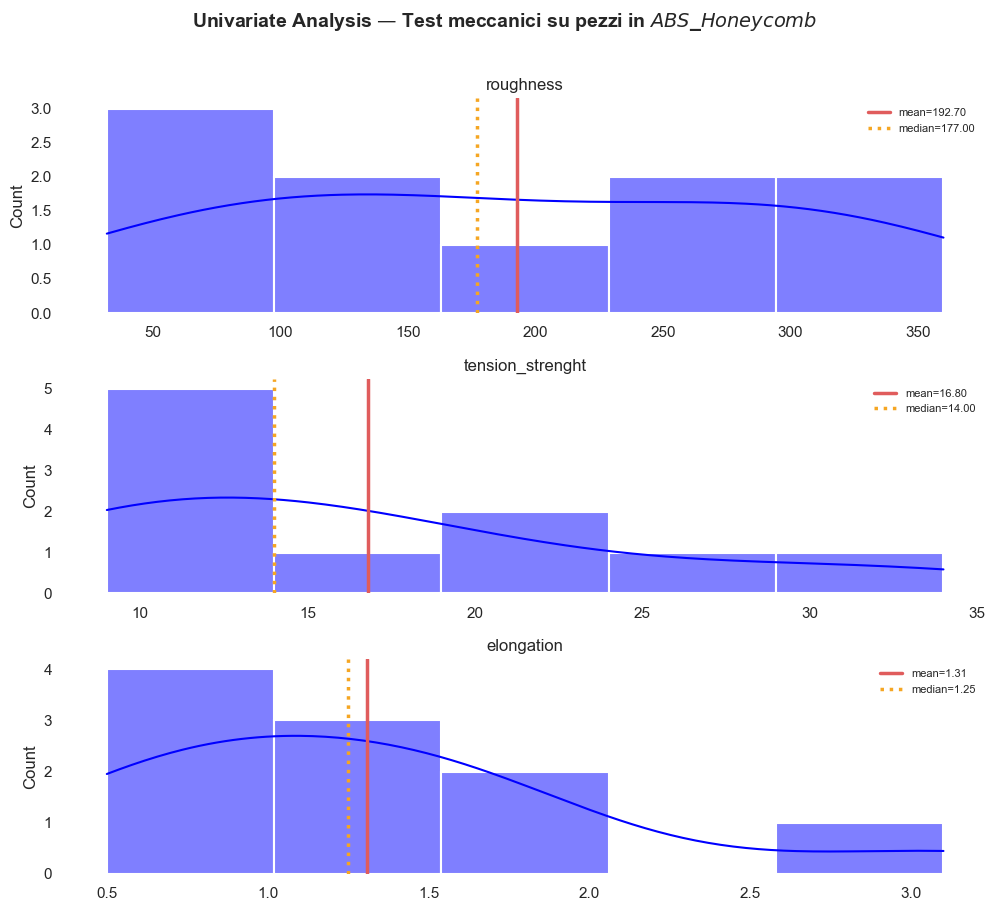

In [910]:
#test meccanici sui pezzi stampati in ABS_Honeycomb
fig, axes = plt.subplots(n2, 1, figsize=(10, n2 * 3), squeeze=False)
fig.suptitle("Univariate Analysis — Test meccanici su pezzi in $\\mathit{ABS}$_$\\mathit{Honeycomb}$", fontsize=14, fontweight="bold", y=1.01)

df_abs_honey=df_abs.query('infill_pattern=="honeycomb"')
for i, col in enumerate(num_cols[-3:]):

    sns.histplot(df_abs_honey[col], ax=axes[i][0], kde=True, color="blue", bins="auto", edgecolor="white", linewidth=1.5)
    
    axes[i][0].axvline(df_abs_honey[col].mean(),   color="#E05C5C", lw=2.5, ls="-", label=f"mean={df_abs_honey[col].mean():.2f}")
    axes[i][0].axvline(df_abs_honey[col].median(), color="#F5A623", lw=2.5, ls=":",  label=f"median={df_abs_honey[col].median():.2f}")
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel("")
    axes[i][0].legend(fontsize=8, frameon=False)
    axes[i][0].grid(False)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("test_meccanici_ABS_Honeycomb.png", bbox_inches="tight")
plt.show()

L'analisi mostra la distribuzione dei risultati dei test meccanici ottenuti sui pezzi in *ABS* nelle due configurazioni di riempimento *Grid* e *Honeycomb*. Dal confronto dei due istogrammi è inoltre possibile notare línfluenza dell'*infill pattern* nelle caratteristiche meccaniche e morfologiche dei pezzi stampati

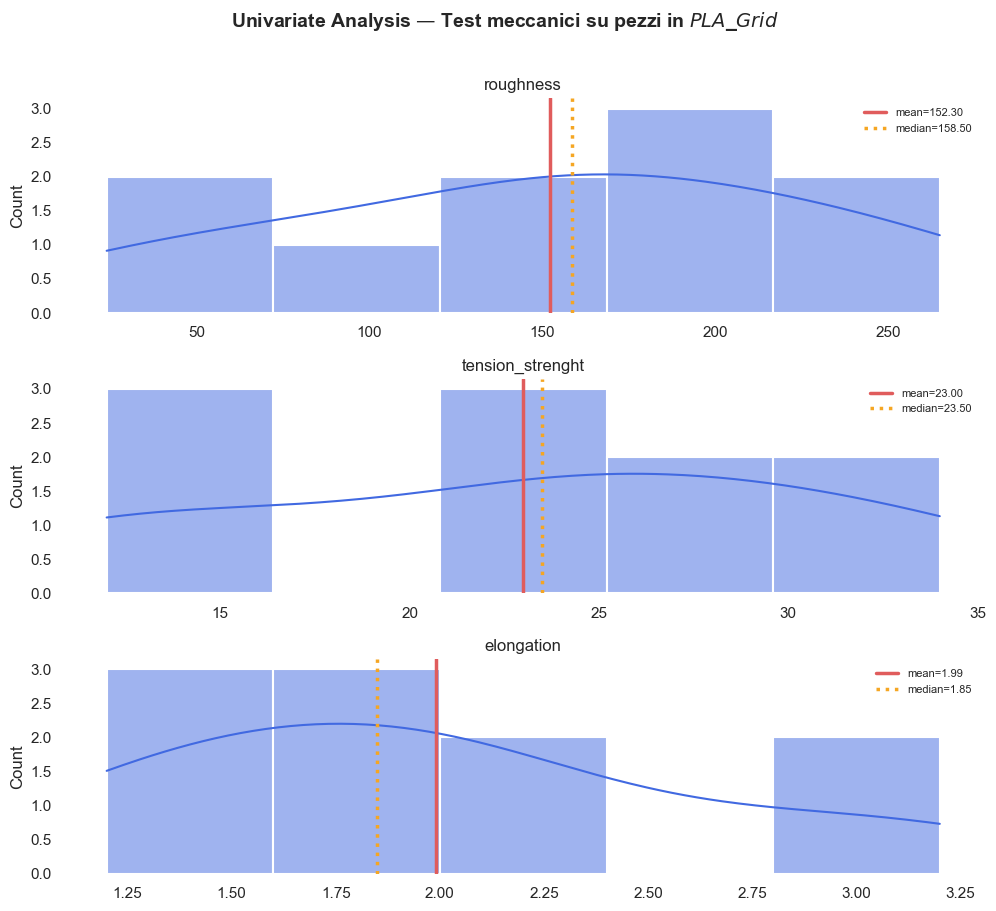

In [912]:
#test meccanici sui pezzi stampati in PLA_Grid
fig, axes = plt.subplots(n2, 1, figsize=(10, n2 * 3), squeeze=False)
fig.suptitle("Univariate Analysis — Test meccanici su pezzi in $\\mathit{PLA}$_$\\mathit{Grid}$", fontsize=14, fontweight="bold", y=1.01)

df_pla_grid=df_pla.query('infill_pattern=="grid"')

for i, col in enumerate(num_cols[-3:]):

    sns.histplot(df_pla_grid[col], ax=axes[i][0], kde=True, color="#4169e1", bins="auto", edgecolor="white", linewidth=1.5)
    
    axes[i][0].axvline(df_pla_grid[col].mean(),  color="#E05C5C", lw=2.5, ls="-", label=f"mean={df_pla_grid[col].mean():.2f}")
    axes[i][0].axvline(df_pla_grid[col].median(), color="#F5A623", lw=2.5, ls=":",  label=f"median={df_pla_grid[col].median():.2f}")
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel("")
    axes[i][0].legend(fontsize=8, frameon=False)
    axes[i][0].grid(False)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("test_meccanici_PLA_Grid.png", bbox_inches="tight")
plt.show()

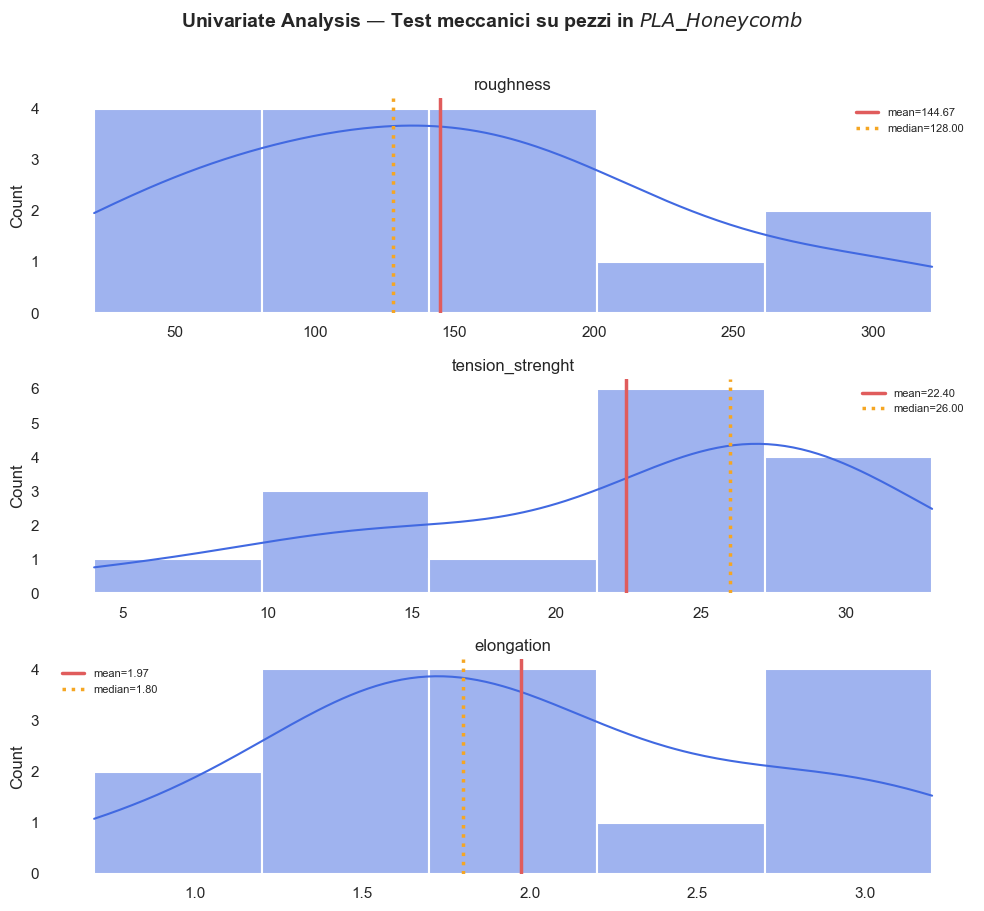

In [913]:
#test meccanici sui pezzi stampati in PLA_Honeycomb
fig, axes = plt.subplots(n2, 1, figsize=(10, n2 * 3), squeeze=False)
fig.suptitle("Univariate Analysis — Test meccanici su pezzi in $\\mathit{PLA}$_$\\mathit{Honeycomb}$", fontsize=14, fontweight="bold", y=1.01)

df_pla_honey=df_pla.query('infill_pattern=="honeycomb"')

for i, col in enumerate(num_cols[-3:]):

    sns.histplot(df_pla_honey[col], ax=axes[i][0], kde=True, color="#4169e1", bins="auto", edgecolor="white", linewidth=1.5)
    
    axes[i][0].axvline(df_pla_honey[col].mean(),  color="#E05C5C", lw=2.5, ls="-", label=f"mean={df_pla_honey[col].mean():.2f}")
    axes[i][0].axvline(df_pla_honey[col].median(), color="#F5A623", lw=2.5, ls=":",  label=f"median={df_pla_honey[col].median():.2f}")
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel("")
    axes[i][0].legend(fontsize=8, frameon=False)
    axes[i][0].grid(False)
    sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("test_meccanici_PLA_Honeycomb.png", bbox_inches="tight")
plt.show()

Analogamente a quanto sopra, si è ricavata la distribuzione dei test meccanici eseguiti su pezzi stampati in *PLA*, evidenziando l'influenza dell'*infill_pattern*.

Dal confronto degli istogrammi sopra si ricava che:
- Il *PLA* garantisce una resistenza a trazione leggermente superiore rispetto all' *ABS* (confrontando la media del **25% superiore**)
- La finitura superficiale dei pezzi stampati in *PLA* è migliore di quelli stampati in *ABS* (**rugosità inferiore in media del 30%**)
- Il *PLA* risulti **più sensibile in termini di rugosità** alla scelta dell' infill pattern utilizzato rispetto all'ABS.
- L'**influenza dell'infill pattern utilizzato è risultata poco significativa** in tutti i test realizzati (rugosità, resistenza e deformazione del pezzo), sia per il *PLA* che per l'*ABS*.

#### 2.2 Analisi di Correlazione

Tramite heatmap verifichiamo quali tra parametri di stampa utilizzati influenzano maggiormente le prorietà meccaniche dei pezzi ottenuti.

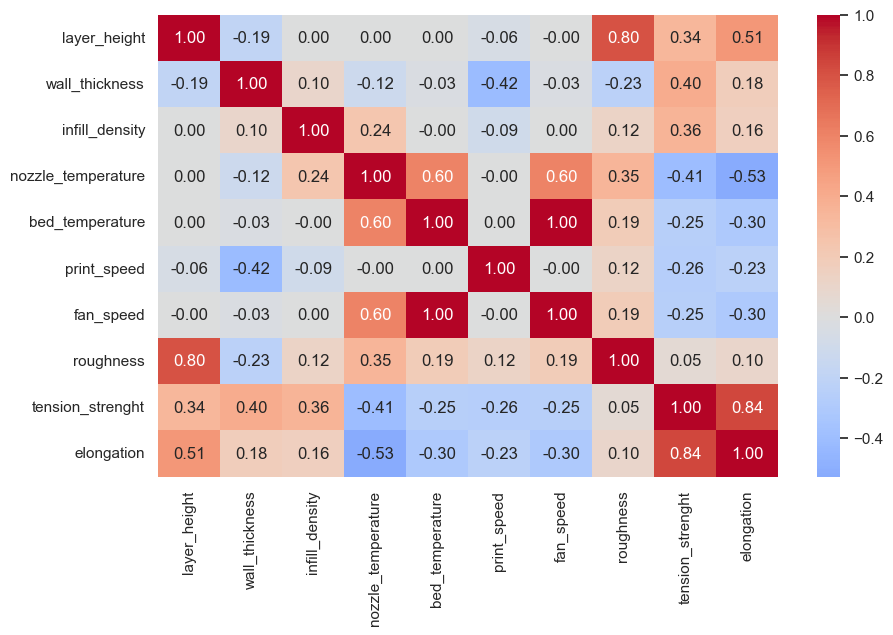

In [918]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

Andremo ad analizzare la correlazione e possibile causalità, evidenziata dalla heatmap, tra:

| | Parametro di stampa | Performance meccaniche | Valore correlazione |
|---|---|---|---|
| 2.2.1 | *Layer height* | *Roughness* | **+0.8** |
| 2.2.2 | *Wall thickness* | *Tension strenght* | **+0.4** |
| | *Infill density* | *Tension strenght* | **+0.36** |
| 2.2.3 | *Nozzle temperature* | *Elongation* | **-0.53** |
| | *Layer height* | *Elongation* | **-0.53** |

OSS: Nella heatmap sopra risultano possedere un'elevata correlazione diretta anche:
- Tension strenght < +0.84 > Elongation: in quanto secondo la curva sforzo-deformazione dei materiali termoplastici all'aumentare dell'UTS aumenta la elengazione massima del materiale;
- bed temperature < +1.0 > fan speed | nozzle temperature < +0.60 > fan speed: parametri legati alla regolazione della temperatura nel processo di stampa -> fortemente correlati

##### 2.2.1 Correlazione Layer height | Roughness

Valutiamo l'influenza dell'altezza del layer sulla finitura superficiale ottenuta, confrontando i due materiali stampati

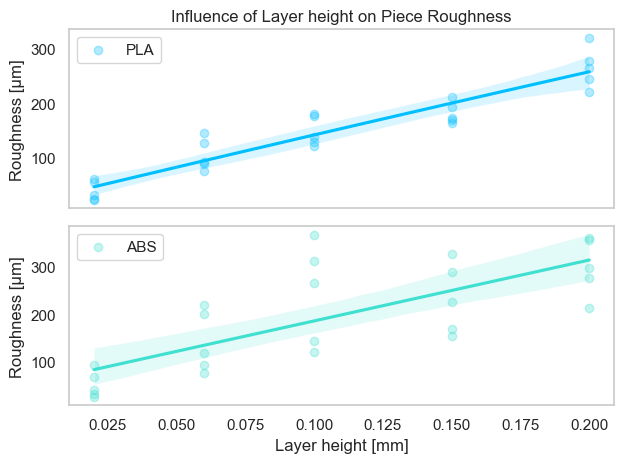

In [923]:
fig, (ax1, ax2)=plt.subplots(nrows=2, ncols=1, sharex=True)

sns.regplot(
    data=df_pla, 
    x='layer_height', 
    y='roughness', 
    color='#00bfff', 
    label='PLA', 
    ax=ax1,
    scatter_kws={'alpha':0.3},
    order=2
)
sns.regplot(
    data=df_abs,
    x='layer_height',
    y='roughness',
    color='#40e0d0',
    label='ABS',
    ax=ax2,
    scatter_kws={'alpha':0.3},
    order=1
)


ax1.legend()
ax1.set_title('Influence of Layer height on Piece Roughness')
ax1.set_xlabel('')
ax1.set_ylabel('Roughness [µm]')
ax1.grid()

ax2.legend()
ax2.set_xlabel('Layer height [mm]')
ax2.set_ylabel('Roughness [µm]')
ax2.grid()

plt.tight_layout()
plt.show()

Si nota una **correlazione lineare: maggiore l'altezza del layer stampato, maggiore la rugosità del pezzo finale (peggiore la finitura superficiale)**

##### 2.2.2 Correlazione Infill Density & Wall thickness | Tension Strenght

Valutiamo l'influenza dell'infill density e Wall thickness sulla resistenza meccanica del materiale, mantenendo separati i comportamenti dei due materiali stampati

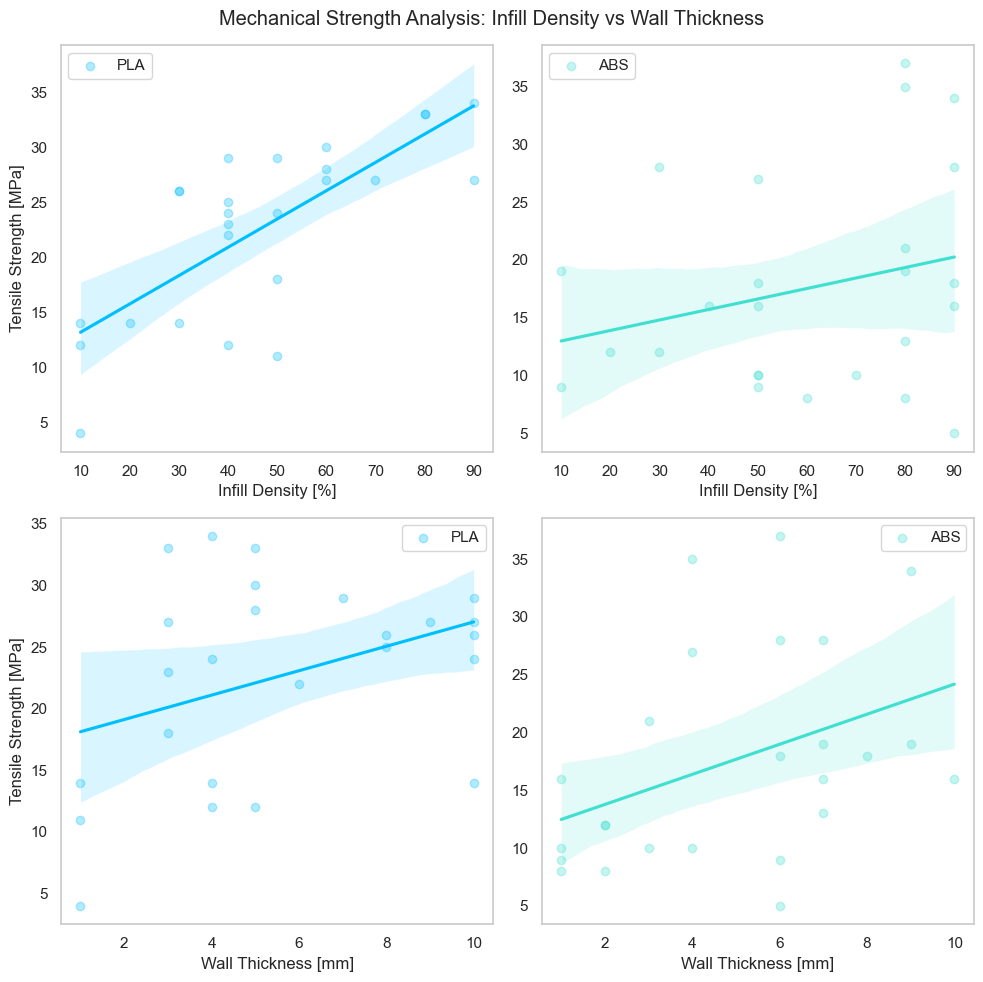

In [927]:
fig, ((ax1, ax2), (ax3, ax4))=plt.subplots(nrows=2, ncols=2, figsize=(10,10))

sns.regplot(
    data=df_pla, 
    x='infill_density', 
    y='tension_strenght', 
    color='#00bfff', 
    label='PLA', 
    ax=ax1,
    scatter_kws={'alpha':0.3},
    order=1
)
sns.regplot(
    data=df_abs,
    x='infill_density',
    y='tension_strenght',
    color='#40e0d0',
    label='ABS',
    ax=ax2,
    scatter_kws={'alpha':0.3},
    order=1
)

sns.regplot(
    data=df_pla, 
    x='wall_thickness', 
    y='tension_strenght', 
    color='#00bfff', 
    label='PLA', 
    ax=ax3,
    scatter_kws={'alpha':0.3},
    order=1
)
sns.regplot(
    data=df_abs,
    x='wall_thickness',
    y='tension_strenght',
    color='#40e0d0',
    label='ABS',
    ax=ax4,
    scatter_kws={'alpha':0.3},
    order=1
)


ax1.legend()
ax1.set_xlabel('Infill Density [%]')
ax1.set_ylabel('Tensile Strength [MPa]')
ax1.grid(False)

ax2.legend()
ax2.set_xlabel('Infill Density [%]')
ax2.set_ylabel('')
ax2.grid(False)

ax3.legend()
ax3.set_xlabel('Wall Thickness [mm]')
ax3.set_ylabel('Tensile Strength [MPa]')
ax3.grid(False)

ax4.legend()
ax4.set_xlabel('Wall Thickness [mm]')
ax4.set_ylabel('')
ax4.grid(False)

fig.suptitle('Mechanical Strength Analysis: Infill Density vs Wall Thickness', y=0.98)
plt.tight_layout()
plt.show()

Come atteso, la **resistenza meccanica del componente stampato 3D FDM aumenta all'aumentare della densità di riempimento e spessore della parete**. Più in dettaglio:
- La variazione positiva dell'infill density porta ad un maggior incremento della resistenza a trazione nei pezzi stampati in PLA.
- L'effetto della wall thickness sull'aumento di resistenza meccanica presenta andamento e magnitudine (slope della retta di regressione) similare nei pezzi stampati in PLA e ABS, con quest'ultimo che presenta una dispersione dei risultati ottenuti superiore.
- Nei pezzi in ABS **la variazione dello spessore di parete influisce maggiormente sulla resistenza meccanica rispetto alla variazione dell'infill density (maggiore coefficiente angolare della curva di regressione)**, mentre nei pezzi in PLA si verifica l'opposto

##### 2.2.3 Nozzle temperature & Fan speed | Elongation

Come gestire il raffreddamento del pezzo per evitare che il materiale infrailisca (ovvero si riduca il suo allungamento a rottura)?

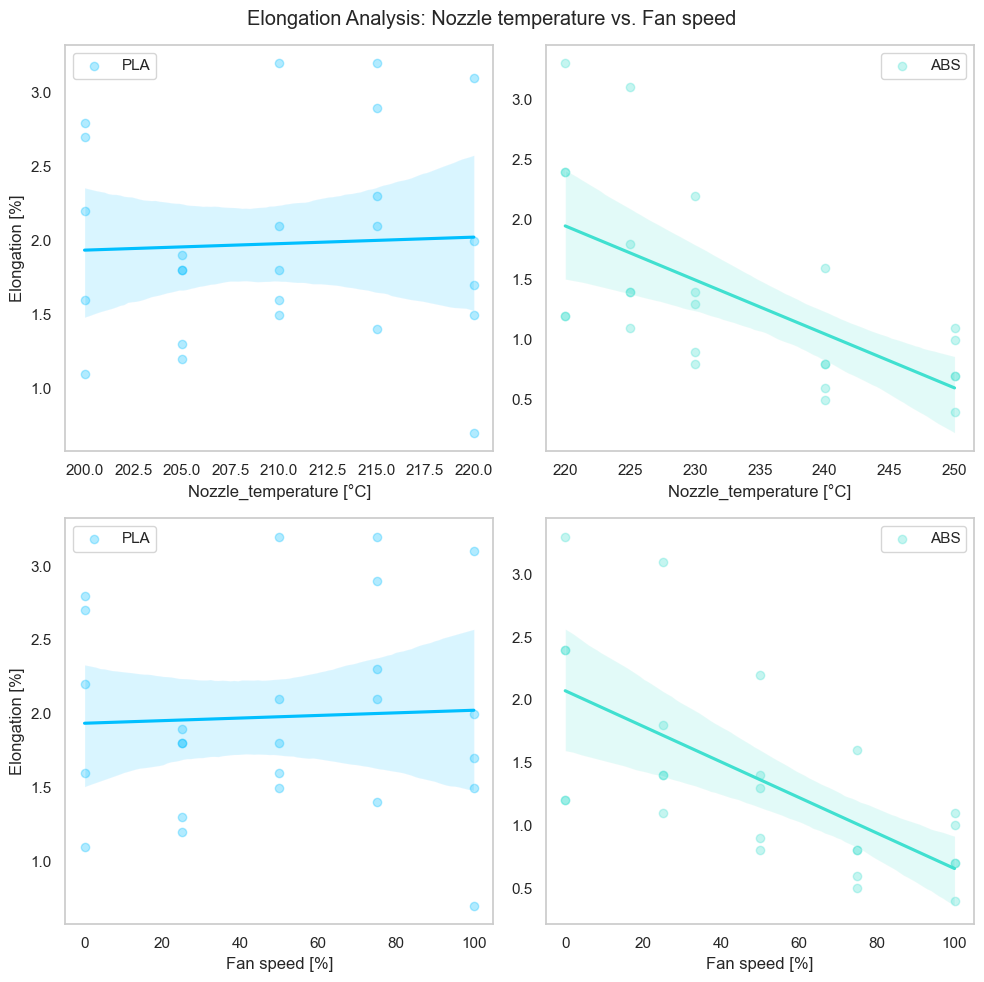

In [931]:
fig, ((ax1, ax2), (ax3, ax4))=plt.subplots(nrows=2, ncols=2, figsize=(10,10))

sns.regplot(
    data=df_pla, 
    x='nozzle_temperature', 
    y='elongation', 
    color='#00bfff', 
    label='PLA', 
    ax=ax1,
    scatter_kws={'alpha':0.3},
    order=1
)
sns.regplot(
    data=df_abs,
    x='nozzle_temperature',
    y='elongation',
    color='#40e0d0',
    label='ABS',
    ax=ax2,
    scatter_kws={'alpha':0.3},
    order=1
)

sns.regplot(
    data=df_pla, 
    x='fan_speed', 
    y='elongation', 
    color='#00bfff', 
    label='PLA', 
    ax=ax3,
    scatter_kws={'alpha':0.3},
    order=1
)
sns.regplot(
    data=df_abs,
    x='fan_speed',
    y='elongation',
    color='#40e0d0',
    label='ABS',
    ax=ax4,
    scatter_kws={'alpha':0.3},
    order=1
)


ax1.legend()
ax1.set_xlabel('Nozzle_temperature [°C]')
ax1.set_ylabel('Elongation [%]')
ax1.grid(False)

ax2.legend()
ax2.set_xlabel('Nozzle_temperature [°C]')
ax2.set_ylabel('')
ax2.grid(False)

ax3.legend()
ax3.set_xlabel('Fan speed [%]')
ax3.set_ylabel('Elongation [%]')
ax3.grid(False)

ax4.legend()
ax4.set_xlabel('Fan speed [%]')
ax4.set_ylabel('')
ax4.grid(False)

fig.suptitle('Elongation Analysis: Nozzle temperature vs. Fan speed', y=0.98)
plt.tight_layout()
plt.show()

Dall'analisi si nota che PLA e ABS hanno un **comportamento termomeccanico notevolmente diverso**:
- I pezzi in PLA, stampati tra 200°C e 220°C, risultano sensibilmente più duttili (maggior allungamento) all'aumentare della temperatura dell'ugello e della velocità della ventola
- I pezzi in ABS,  stampati tra 220°C e 250°C, risultano essere molto più sensibili alle condizioni termiche con cui avviene il processo. In particolare la duttilità del pezzo si riduce visibilmente (passando dal 2.5% al 0.5%) all'aumentare della temperatura dell'ugello e della velocità di raffreddamento data dalle ventole della stampante

Si possono dunque trarre le seguenti conclusioni nella gestione delle temperature durante la stampa 3D FDM del PLA ed ABS:
- Per il **PLA la massima elastiticà (elongation) si ottiene stampando con temperature di ugello tra i 210-220°C con una ventola ad alta velocità**
- Per **l'ABS la duttilità crolla all'aumentare della temperatura dell'ugello e della velocità di raffreddamento (optare per una stampa a ventola spenta)**

## 3. Data Prediction

In [934]:
#importazione librerie
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#### 3.1 Modello di predizione della Rugosità

E' stato utilizzato un **modello di regressione lineare** per cercare di descrivere il fenomeno con una funzione il più semplice possible. 

Avendo il dataset solo 50 records, per ottenere un **modello di regressione lineare** più robusto *non verranno inserite tutte le features (meno variabili -> modello più stabile) ma solo quelle che abbiamo visto (matrice di correlazione) essere maggiormente correlate alla rugosità (e con una tendenza apparentemente lineare intercettabile dal modello)*, ovvero *layer_height*, *nozzle_temperature*, *wall thickness* e ovviamente *material*. Anche l'infill_pattern avevamo visto non influenzare le proprietà meccaniche e morfologiche del materiale quindi viene escluso dalle features su cui verrà costruito il modello.

##### Preparazione e training del modello

In [938]:
#Definizione delle varibiali - features e target
X = df[['layer_height', 'nozzle_temperature', 'wall_thickness','material']]  #features selezionate
y = df['roughness']   #target

#Costruzione della PIPELINE - Preprocessing & Inizializzazione Modello di regressione lineare

#Preprocessing
numerical_features = ['layer_height', 'nozzle_temperature', 'wall_thickness'] #variabili numeriche
categorical_features = ['material']   #variabili categoriche

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_features),   #standardizzazione delle colonne numeriche tramite StandardScaler
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)  #encoding delle varibili categoriche (0-1) tramite OneHot
         ])                                                                                          #drop='first' porta il modello a scegliere un materiale come "punto di partenza" (la baseline) e lo nasconde dentro l'intercetta.

#Definizione della Pipeline: Preprocessing + Modello di regressione lineare
linear_model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())]
)


#Split dei dati (80% training-20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

#Addestramento del modello sul training set
linear_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['layer_height',
                                                   'nozzle_temperature',
                                                   'wall_thickness']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['material'])])),
                ('regressor', LinearRegression())])

##### Predizione utilizzando il modello e valutazione performance

In [940]:
#Predizione utilizzando il modello e valutazione delle performance tramite le metriche di valutazione dei modelli di regressione
y_pred = linear_model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("-"*70)
print("      PERFORMANCE MODELLO DI REGRESSIONE LINEARE - RUGOSITA'      ")
print("-"*70)
print(f"MAE (Errore Medio Assoluto):       {mae:.2f}")
print(f"RMSE (Radice Errore Quad. Medio):  {rmse:.2f}")
print(f"R² Score (Varianza Spiegata):      {r2:.2f}")
print("-"*70)

----------------------------------------------------------------------
      PERFORMANCE MODELLO DI REGRESSIONE LINEARE - RUGOSITA'      
----------------------------------------------------------------------
MAE (Errore Medio Assoluto):       31.21
RMSE (Radice Errore Quad. Medio):  33.77
R² Score (Varianza Spiegata):      0.81
----------------------------------------------------------------------


Tenendo conto che la rugosità dei pezzi testati presenti nel dataframe con cui è stato addestrato il modello ha un valore medio di 170µm con una (*elevata!*) deviazione standard di 99, possiamo valutare che:
- Il **MAE** ricavato ha un valore **accettabile (abbastanza basso) rispetto alla deviazione standard della rugosità presente nel dataframe (MAE < 1/2 STD)**
- L'**RMSE è circa uguale al MAE**, significa che il modello fa errori piccoli e uniformi (non fa errori enormi)
- L'**R2 è >0.70** che è un valore molto buono contando che il modello è stato addestrato su un dataset reale con rumore e sole 50 righe.

##### Grafici di valutazione del modello predittivo

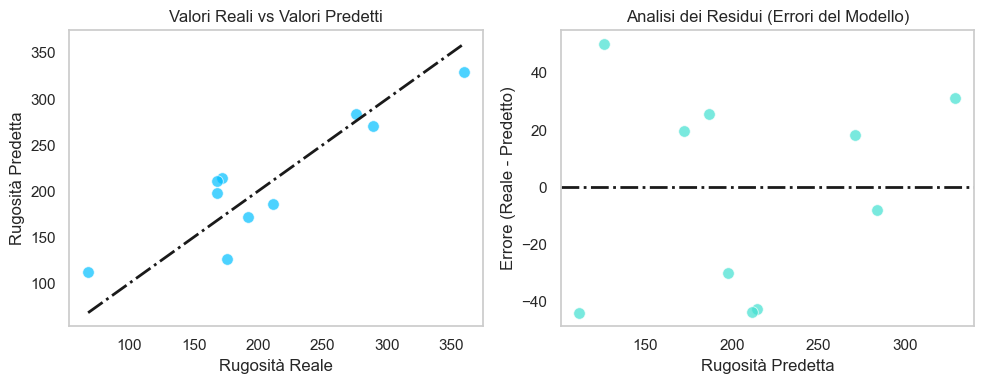

In [943]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

#Grafico 1: Valori Reali vs Valori Predetti
sns.scatterplot(x=y_test, y=y_pred, ax=ax1, color='#00bfff', alpha=0.7, s= 70)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k-.', lw=2) # Linea di predizione perfetta

ax1.set_title('Valori Reali vs Valori Predetti')
ax1.set_xlabel('Rugosità Reale')
ax1.set_ylabel('Rugosità Predetta')
ax1.grid(False)

#Grafico 2: Analisi dei Residui (Errori)
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, ax=ax2, color='#40e0d0', alpha=0.7, s=70)
ax2.axhline(y=0, color='k', linestyle='-.', lw=2)    #Baseline errore nullo

ax2.set_title('Analisi dei Residui (Errori del Modello)')
ax2.set_xlabel('Rugosità Predetta')
ax2.set_ylabel('Errore (Reale - Predetto)')
ax2.grid(False)

plt.tight_layout()
plt.show()

- A dimostrazione del buon valore di R2 ottenuto, i punti predetti nel grafico Valori Predetti vs. Valori Reali si distribuscono attorno alla retta y=x (linea di predizione perfetta)
- Dal grafico dei Rasidui si evince come gli errori ottenuti per le varie rugosità predette non manifestino alcun pattern (es. alti errori per basse rugosità, o viceversa) ma sono sparsi casualmente attorno alla linea di errore nullo, a dimostrazione che l'errore ottenuto è casuale ed il modello riesce a predirre senza alte variazioni in tutto il dominio considerato

##### Equazione matematica del modello

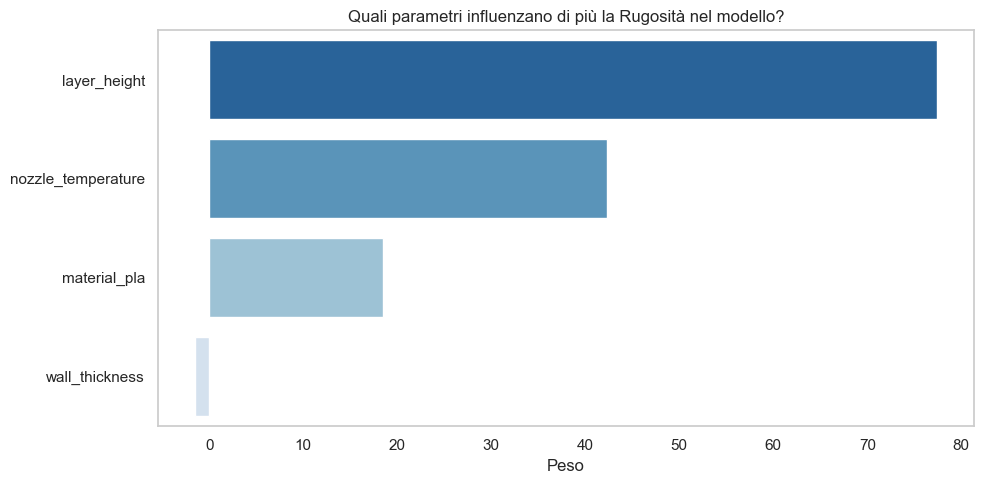

------------------------------------------------------------------------------------------------------------------------
                                **EQUAZIONE DELLA RETTA DI REGRESSIONE LINARE**      
------------------------------------------------------------------------------------------------------------------------
Roughness = 151.96 +( 77.4)*layer_height + (42.31)*nozzle_temperature + (-1.47)*wall_thickness + (18.48)*material_pla
------------------------------------------------------------------------------------------------------------------------


In [946]:
#Recupero dei nomi corretti delle feature dopo la trasformazione One-Hot
encoded_cat_names = linear_model_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features).tolist()
all_features_names = numerical_features + encoded_cat_names

#Estrazione intercetta e coefficienti dell'equazione lineare
coefficients = linear_model_pipeline.named_steps['regressor'].coef_.round(2)
intercept = linear_model_pipeline.named_steps['regressor'].intercept_.round(2)

#Plot Parametri vs. Coefficienti
coef_df = pd.DataFrame({'Parametro': all_features_names, 'Coefficiente': coefficients})
coef_df = coef_df.sort_values(by='Coefficiente', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Coefficiente', y='Parametro', data=coef_df, hue='Parametro',palette='Blues_r')
plt.title('Quali parametri influenzano di più la Rugosità nel modello?')
plt.xlabel('Peso')
plt.ylabel('')
plt.grid(False)
plt.tight_layout()
plt.show()

#Print retta di regressione lineare
print("-"*120)
print('                                **EQUAZIONE DELLA RETTA DI REGRESSIONE LINARE**      ')
print("-"*120)
print(f"Roughness = {intercept} +( {coefficients[0]})*{all_features_names[0]} + ({coefficients[1]})*{all_features_names[1]} + \
({coefficients[2]})*{all_features_names[2]} + ({coefficients[3]})*{all_features_names[3]}")
print("-"*120)

Il **maggior peso** nella predizione del modello della rugosità del pezzo stampato 3D è dato dall' **altezza del layer**, seguito dalla **temperatura dell'ugello**. Si potrebbe eliminare la *wall thickness* dall'equazione, e di conseguenza dalle features con cui è stato addestrato il modello (portando ad una plausibile diminuzione dell'errore di predizione) in quanto il suo peso risulta pressochè neutro.


**NB**: Nell'equazione si nota la sola presenza del peso dato dal materiale considerato PLA, in quanto il contributo alla determinazione della rugosità dato dal materiale ABS, per come è stato costruito il modello (vedi *Par.* "*Preparazione e training del modello*"), è gia contenuta nell'intercetta dell'equazione. Tale parametro risulta dunque un *coefficiente di correzione sulla base del materiale scelto per la stampa*, che si annulla nel caso di stampa con materiale ABS.

Gli altri parametri di stampa, come indicato nelle condizioni iniziali con cui è stato costruito il modello, non sono presenti nell'equazioni in quanto non correlati alla rugosità. 

##### Valutazione stabilità del modello tramite K-fold Cross Validation

la Cross-Validation mescola e divide il dataset in $K$ parti (es. 5). Il modello viene addestrato 5 volte, usando ogni volta una parte diversa come test e le altre come train.Se l' $R^2$ rimane stabile in tutte e 5 le prove, il tuo modello è robusto. Se in una prova fa 0.85 e in un'altra fa 0.30, il modello è instabile.

In [950]:
from sklearn.model_selection import cross_val_score

#Calcolo dell'R² su 3 combinazioni differenti di dati
n_folds=3
scores = cross_val_score(linear_model_pipeline, X, y, cv=n_folds, scoring='r2').round(2)

print("-"*70)
print(F"      RISULTATI K-FOLD CROSS VALIDATION | K={n_folds}")
print("-"*70)
print(f"R² di ogni fold: {scores} \n")
print(f"R² Medio: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")
print("-"*70)

----------------------------------------------------------------------
      RISULTATI K-FOLD CROSS VALIDATION | K=3
----------------------------------------------------------------------
R² di ogni fold: [0.22 0.41 0.3 ] 

R² Medio: 0.31 (+/- 0.16)
----------------------------------------------------------------------


Notiamo che l'R2 del modello addestrato sulle varie fold ha una grande varianza e risulta nettamente più basso -> **il limite che porta il modello ad essere così instabile è la ridotta dimensione del dataframe utilizzato per l'addestramento del modello (50 records)**. 
L'affidabilità del framework utilizzato per la realizzazione del modello deve essere dunque validata tramite una base dati più ampia.

Va inoltre valutata l'efficacia di utilizzare un modello più complesso (*modello di Regressione Polinomiale* o *Random Forest Regressor*) in grado di individuare correlazioni non lineari tra features e target ed ottenere risultati predittivi più soddisfacenti anche con un dataset così ristretto.

#### 3.2 Modello di predizione della Resistenza meccanica

Per la più alta complessità in gioco non utilizzeremo più un modello di regressione lineare ma un **modello Random Forest Regressor**, che *gestisce meglio relazioni non lineari tra features e target ed interazioni tra features stesse (effetti sinergici)*: ad esempio, una bassa infill_density fa crollare la resistenza meccanica del pezzo solo se anche la wall_thickness è sottile, mentre se la parete è molto spessa l'infill conta meno.

Consideriamo ancora una volta, viste le poche prove su cui addestrare il modello, solo le feauters significative (vedi matrice di correlazione) che sono maggiormente correlate con la tension strenght del pezzo stampato 3D FDM, ovvero *layer_height, wall_thickness, infill_density, nozzle_temperaturem, material e infill_pattern*. In questo modo il modello viene alleggerito da parametri non importanti che porterebbero solo ad un'amplificazione inutile dell'errore (il modello tende a perdersi con troppe features e così pochi dati disponibili per l'addestramento).

##### Preparazione e training del modello

In [955]:
from sklearn.ensemble import RandomForestRegressor

X2 = df.drop(columns=['roughness','elongation','tension_strenght','print_speed', 'fan_speed','bed_temperature'])
y2 = df['tension_strenght']

numerical_features2 = ['layer_height', 'wall_thickness','infill_density','nozzle_temperature'] 
categorical_features2 = ['infill_pattern', 'material']  

preprocessor2 = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_features2),   
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features2)  
         ])                                                                                          


random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor2), # Il preprocessor rimane lo stesso di prima
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=4, random_state=10))
])

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=15)

random_forest_pipeline.fit(X2_train, y2_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['layer_height',
                                                   'wall_thickness',
                                                   'infill_density',
                                                   'nozzle_temperature']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['infill_pattern',
                                                   'material'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=4, n_estimators=50,
                                       random_state=10))])

##### Predizione utilizzando il modello e valutazione performance

In [957]:
y2_pred=random_forest_pipeline.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_test2 = r2_score(y2_test, y2_pred)

print("-"*70)
print("     PERFORMANCE MODELLO RANDOM FOREST - RESISTENZA A TRAZIONE    ")
print("-"*70)
print(f"MAE (Errore Medio Assoluto):       {mae2:.2f}")
print(f"RMSE (Radice Errore Quad. Medio):  {rmse2:.2f}")
print(f"R² Score sul Test Set:             {r2_test2:.2f}")
print("-"*70)

----------------------------------------------------------------------
     PERFORMANCE MODELLO RANDOM FOREST - RESISTENZA A TRAZIONE    
----------------------------------------------------------------------
MAE (Errore Medio Assoluto):       4.84
RMSE (Radice Errore Quad. Medio):  5.80
R² Score sul Test Set:             0.55
----------------------------------------------------------------------


- Il **MAE** ottenuto **non è basso rispetto alla tension strenght (media=20 con std=8)** dei pezzi a dataframe, ovvero il modello predice valori con un errore medio di 5 MPa su una tensione di rottura media di 20 Mpa 
- L'**RMSE è circa uguale al MAE**, significa che il modello sbeglia in modo uniforme senza commettere errori enormi.
- L'**R2 è 0,55**: Il modello riesce a spiegare il 55% della variabilità della resistenza a trazione basandosi sui parametri di stampa inseriti. Tale valore risulta così basso sempre a causa del ristretto numero di records (50) con cui è stato addestrato il modello, oltre che a fenomeni più complessi relativi al processo di stampaggio 3D FDM, che vanno oltre l'influenza dei parametri di stampa considerati.

##### Valutazione stabilità del modello tramite Repeated K-fold Validation

In [998]:
from sklearn.model_selection import RepeatedKFold

n_folds=3
n_reps=5

cv_stabile = RepeatedKFold(n_splits=n_folds, n_repeats=n_reps, random_state=12)
scores_rf = cross_val_score(random_forest_pipeline, X2, y2, cv=cv_stabile, scoring='r2')

print("-"*90)
print(F"      RISULTATI REPEATED K-FOLD CROSS VALIDATION | K={n_folds} | REPS={n_reps}")
print("-"*90)
print(f"R² di ogni fold: {scores_rf}")
print(f"\nR² Medio (Cross-Validation):       {scores_rf.mean():.4f} (+/- {scores_rf.std() * 2:.4f})")
print("-"*90)

------------------------------------------------------------------------------------------
      RISULTATI REPEATED K-FOLD CROSS VALIDATION | K=3 | REPS=5
------------------------------------------------------------------------------------------
R² di ogni fold: [0.57165229 0.52227291 0.62996586 0.55164274 0.6581412  0.43099356
 0.63169058 0.54820813 0.28544945 0.46346017 0.58936924 0.47963441
 0.51775262 0.69140106 0.37360034]

R² Medio (Cross-Validation):       0.5297 (+/- 0.2130)
------------------------------------------------------------------------------------------


L'R2 medio ricavato tramite cross-validation si attesta sui valori di quello ricavato addestrando il modello su singolo split -> **il modello è stabile**

##### Valutazione importanza dei parametri sulla predizione della resistenza a trazione

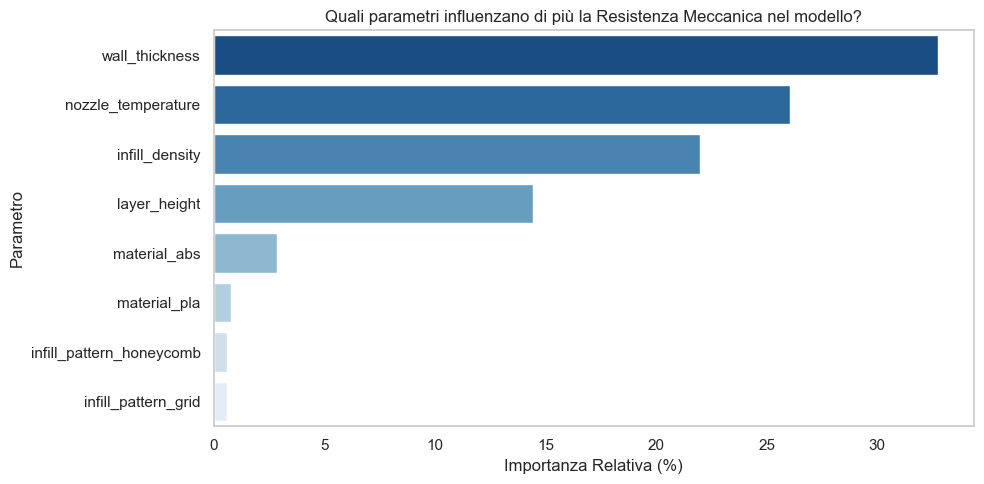

In [963]:
#Recupero dei nomi corretti delle feature dopo la trasformazione One-Hot
encoded_cat_names2 = random_forest_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features2).tolist()
all_features_names2 = numerical_features2 + encoded_cat_names2

#Importanza dei singoli parametri sulla resistenza meccanica
importances = random_forest_pipeline.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({'Parametro': all_features_names2, 'Importanza (%)': importances * 100})
importance_df = importance_df.sort_values(by='Importanza (%)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importanza (%)', y='Parametro', hue='Parametro', data=importance_df, palette='Blues_r')
plt.title('Quali parametri influenzano di più la Resistenza Meccanica nel modello?')
plt.xlabel('Importanza Relativa (%)')
plt.ylabel('Parametro')
plt.grid(False)
plt.tight_layout()
plt.show()

## 4. Conclusioni

Dall' analisi dei parametri di stampa 3D impostati e del comportamento meccanico ottenuto dai pezzi testati è stato possibile ricavare le seguenti considerazioni:
- Il PLA garantisce una **resistenza a trazione in media del 25% superiore all' ABS ed una rugosità media inferiore del 30%** (miglior finitura superficiale)
- **L'influenza dell'infill pattern utilizzato (*Grid* e *Honeycomb*) è risultata poco significativa in tutti i test realizzati** (rugosità, resistenza e deformazione del pezzo), sia per il PLA che per l'ABS.
- Esiste una **forte correlazione lineare tra rugosità ottenuta sul pezzo stampato e altezza del layer impostata**: maggiore l'altezza del layer, maggiore la rugosità del pezzo finale (peggiore la finitura superficiale)
- **La resistenza meccanica del componente aumenta all'aumentare della densità di riempimento e spessore della parete**. Più in dettaglio:
    - La variazione dell'*infill density* ha maggior effetto nei pezzi stampati in PLA;
    - La variazione della *wall thickness* da un contributo similare nei pezzi stampati in PLA e ABS.
- Da confronto del **comportamento termomeccanico dei pezzi stampati 3D in PLA e ABS si nota una tendenza notevolemente differente**:
    - I pezzi in PLA, stampati tra 200°C e 220°C, risultano sensibilmente *più duttili (maggior allungamento) all'aumentare della temperatura dell'ugello e della velocità della ventola*;
    - I pezzi in ABS, stampati tra 220°C e 250°C, risultano essere molto più sensibili alle condizioni termiche con cui avviene il processo. In particolare *la duttilità del pezzo si riduce visibilmente (passando dal 2.5% al 0.5%) all'aumentare della temperatura dell'ugello e della velocità di raffreddamento data dalle ventole della stampante*.

Dalla costruzione dei modelli predittivi per la valutazione della rugosità e resistenza meccanica conoscendo i parametri di stampa 3D impostati sono state tratte le seguenti conclusioni:
- Si è cercato di implementare un **modello di regressione lineare per predirre la rugosità**, cercando un bilanciamento tra semplicità del modello ed accuratezza. A tale scopo sono state utilizzate nell'ingegnerizzazione del modello solamente le features maggiormente correlate, ovvero layer_height, nozzle_temperature, wall thickness e material. Il modello così costruito ha dato risultati interessanti (*MAE e RMSE simili ed abbastanza contenuti, R2 pari a 0,81*), ed è sintetizzato dall'equazione (vedi *Par. 3.2*):

  *Roughness = 151.96 + ( 77.4) x layer_height + (42.31) x nozzle_temperature + (-1.47) x wall_thickness + (18.48)x material_pla*

    I risultati evidenziano come l'altezza del layer e la temperatura dell'ugello rappresentino le variabili con il maggiore impatto sulla determinazione della rugosità del pezzo stampato.
    Tuttavia, a *seguito di cross-validation con k=3 fold, si è notata una certa instabilità del modello* (notevole peggioramento dell'R2), la cui causa è stata ipotizzata *derivante dal ristretto numero di dati con cui viene addestrato il modello (50 record)* che quindi non è in grado di generalizzare la previsione. **L'adeguatezza e robustezza del modello di regressione lineare andrebbe dunque verificata con un bacino di dati disponibili superiore**.

- E' stato costruito un **modello di predizione della resistenza meccanica** dei pezzi tramite **Random Forest Regressor**, che gestisce meglio relazioni non lineari tra features e target ed interazioni tra features stesse (effetti sinergici). Analogamente al modello precedente, le feauters con cui è stato addestrato il modello sono state ridotte per minimizzare il rumore (visti i pochi dati disponibili), selezionandole tramite valutazione della matrice di correlazione: *layer_height, wall_thickness, infill_density, nozzle_temperaturem, material e infill_pattern*.
Dal testing del modello sono state ottenute le seguenti metriche:

    - MAE (e RMSE) medio pari a 5 (Mpa) che rapportato ad una tensione di rottura media dei dataset di 20 Mpa (std=8 MPa) è un incertezza da migliorare
    - R2 pari a 0,55, ovvero il modello riesce a spiegare il 55% della variabilità della resistenza a trazione con i parametri di stampa inseriti. Non un valore elevato ma una buona base di partenza.
            
    La validazione del modello tramite *Repeated K-fold validation* ha dato questa volta risulati positivi, a dimostrazione della stabilità dello stesso nonostante la piccola mole di dati con cui è stato addestrato.